<a href="https://colab.research.google.com/github/adombe/Machine_Learning_2026/blob/main/Andrea_Dombe_T8_torch_NN_pipeline_and_questions_for_assign_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Pipeline for deep learning with PyTorch**

## Major steps from data to deployment

| Step                | Key Actions                                                                | Main PyTorch Classes/Methods                  |
|---------------------|----------------------------------------------------------------------------|-----------------------------------------------|
| Data Preparation    | Load, transform, batch, and split data                                     | `torch.utils.data.Dataset`, `DataLoader`, `torchvision.transforms`  |
| Model Development   | Define architecture, choose loss/optimizer, set hyperparameters            | `torch.nn.Module`, `torch.nn.Parameter`, `torch.nn.functional`, `torch.optim` |
| Model Training      | Forward pass, loss computation, backward pass, parameter update, epochs    | `forward()`, `loss.backward()`, `optimizer.step()`, `optimizer.zero_grad()` , `model.train()` |
| Validation          | Evaluate on validation set, compute metrics, tune hyperparameters          | `model.eval()`, `torch.no_grad()`, metric functions (e.g., `torchmetrics`) |
| Testing/Deployment  | Final evaluation on test set, save and deploy model                        | `torch.save()`, `torch.load()`, `model.eval()`, `torch.jit` |

## Typical training loop.

Recall that the whole set of examples is visited during one epoch. Moreover, the *dataloader* groups examples in batches, and defines some other functionalities like shuffling the examples each time the iterator is created with `for inputs, targets in dataloader` in the example below.

For standard neural network training in PyTorch, inputs and targets should be tensors. This can be dealt with in the *data preparation* step, using `transforms` when creating the custom `Dataset` class for the problem at hand (see https://github.com/isa-ulisboa/greends-pml/blob/main/notebooks/T6_pytorch_dataset_dataloader.ipynb).

As discussed in https://github.com/isa-ulisboa/greends-pml/blob/main/docs/T1_basic_concepts.md for a simple linear regression problem, PyTorch uses **backpropagation** as the strategy to updates the model weights for loss minimization. The exact same idea can be generalized to multilayer neural networks and deep-learning.

The typical training loop in PyTorch is described in the code below.
1. The forward pass is done with `model(inputs)` that applies the model to the input and computes the output. This is a probability distribution over the possible labels.
2. The backward pass is done with `optimizer.step()` using the gradient computed with `loss.backward()`. The loss, as always, depends on the actual output `target` and the predicted output `outputs`. The line of code `optimizer.zero_grad()` prevents the gradients to be summed up along the process. For  backpropagation to work, the model must be in training mode, which it is set by default or by setting `model.train()`.

  ```
  for epoch in range(num_epochs):
      for inputs, targets in dataloader:
          optimizer.zero_grad()
          outputs = model(inputs)
          loss = criterion(outputs, targets)
          loss.backward()
          optimizer.step()
  ```

## Example for data preparation and model training: the MNIST data set

### Step 1: Data preparation

In [1]:
!pip install torchvision

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import time

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),             # Convert to tensor
    transforms.Lambda(lambda x: x.view(-1))  # Flatten the tensor
])

# Load the MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.13MB/s]


**Question**. Dataloaders `train_loader` and `test_loader` are iterators which allow to access examples and labels.
- What is the type of objects yielded by the train and test dataloaders?
**Answer:** The `trainloader` and `testloader` return pairs of tensors: `(images, labels)`.
   `images` contains a batch of input images, while `labels` contains the correct class for each image in that batch.
- What is the *shape* of `images` returned by `for images, labels in train_loader`? How do you interpret that shape?
**Answer:**   Each image is originally 28x28 pixels and then flattened into a single vector. So the shape of `images` is `(batch_size, 784)`, where 784 comes from 28×28 pixels.
- Why dataloaders for train and test differ with respect to the option `shuffle`?
**Answer:**  Training data is shuffled so the model doesn’t learn patterns based on the order of the data. This usually helps the model generalize better.
   For testing, shuffling isn’t necessary because we only want a consistent and reliable evaluation.

#### Visualize some examples and labels

Since the `transform` that was applied above returns flattened tensors, one needs to unflatten them to be able to create an image that can be plotted.

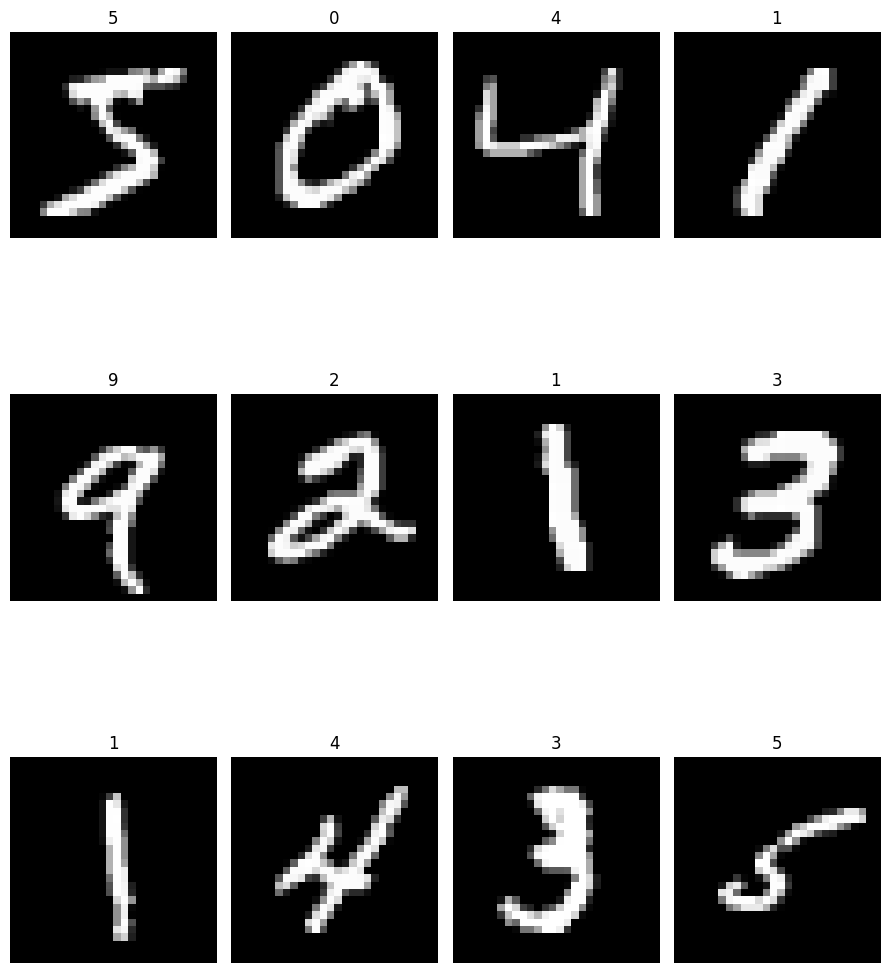

In [6]:
# Images are 28x28 pixels, flattened to a 1D tensor of length 784.
images, labels = zip(*[train_dataset[i] for i in range(12)]) # Visualize only the first 12 examples

fig, axes = plt.subplots(3, 4, figsize=(9, 12))
for i, ax in enumerate(axes.flat):
    img = images[i].reshape(28, 28)  # Unflatten to 2D (28x28)
    ax.imshow(img, cmap='gray')
    ax.set_title(str(labels[i]), fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.show()

### Step 2: model development

In [7]:
# Model Development: the model is a multilayer perceptron with one hidden layer
class SimpleNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(SimpleNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out

# Since we are using 28x28 MNIST and flatenning the input, the input size is 28 * 28 = 784
input_size = 28 * 28
hidden_size = 128
num_classes = 10 # 0-9 digits

model = SimpleNN(input_size, hidden_size, num_classes)

**Question**:
- The model architecture depends on the input data shape. The input images of MNIST are originally of size $28 \times 28$ pixels. Which changes do you need to do if you want to use a different input size? Indicate two changes you need to do in this notebook.
**Answer:**  You would need to:

* Adjust the `transforms` to resize the images to your desired size (e.g., `transforms.Resize((new_width, new_height))`).
* Change the model's `input_size` to `new_width * new_height`.

Since MNIST images are originally 28×28, the flattened input size is 784. If you were to resize them to, say, 8x8, the input size would become 64.

- Which change you need to do in the `SimpleNN` class if you want your model to have two hidden layers, both with size 128?
**Answer:**  You need to add another hidden layer to the network. A possible setup is:

```python
fc1 = nn.Linear(input_size, 128)
fc2 = nn.Linear(128, 128)
fc3 = nn.Linear(128, num_classes)
```
Then apply `ReLU` after both hidden layers in the `forward` function.

- What is a `ReLU` activation function called by `nn.ReLU`?
**Answer:**   `nn.ReLU` is the ReLU activation function, short for Rectified Linear Unit.

- Why are non linear activation functions like `ReLU` necessary for deep learning?
**Answer:**   Without nonlinear activation functions, multiple linear layers would behave the same as a single linear layer.
   ReLU allows the network to learn more complex patterns and relationships in the data.

In [9]:
# Loss and optimizer: necessary for training
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### Some details about cross entropy, softmax, one hot encoding and distributions

Since the problem is a *classification problem*, the criterion to compare model predictions with actual labels (what was denoted be $y$ and $\hat{y}$ for regression) is typically `criterion = nn.CrossEntropyLoss()`. This function has two arguments:
1. the output of the model (a list of scores returned by the model for each possible class, where the largest score corresponds to the most likely class) and
2. the target, which is the actual label of example. For instance if there are 10 classes $0, 1, \dots, 9$, the output would be a list like $[0.3,1.2,2.5,0.2,...]$ with 10 values, and the target could be 2 for instance.

The `nn.CrossEntropyLoss()` function will internally process the scores an the target the following way.

1. **Scores**. The unormalized model outputs $f_1, \dots, f_k$ are called *scores*, *logits* or *raw* outputs. Each score $z_i=f_i({\rm \bf x};{\rm \bf w_i})$ is converted into a [0,1] value by the *softmax* function:
$$p_i=\frac{\exp(z_i)}{\sum_{j=1}^k \exp(z_j)} ~~ {\rm which~implies~that} ~~ 0<p_i \le 1.$$
After that transformation, the classification model's probabilistic output is a vector of values $(p_1,\dots,p_k)$, with $p_i \ge 0$ and $\sum p_i=1$ as required for  probability distributions. The predicted label is the one with highest $p$.

<img src="https://drive.google.com/uc?export=view&id=1iD519g8QbBmOGp9SiOQsIneJnWg53SMQ" width="600" >


2. **Target**. A target value of, say, 2 is one-hot-encoded into the list $[0,0,1,0,...,0]$ of length 10.

The **cross-entropy loss** measures the dissimilarity between the probability distribution returned by *softmax* $(p_1,p_2,\dots)$ and the one hor encoded target distribution $(t_1,t_2,\dots)$ for each example. Its value range from 0 (optimal value associated to minimum uncertainty) and 1 (maximum value associated to maximum uncertainty, i.e. all probabilities are equal):

$$L_{single~example}=-\left( t_1 \, \log(p_1) + t_2 \, \log(p_2) + \dots \right) \in [0,1].$$

In the expression above, we suppose that the probabilities $p_i$ are non zero which is guaranteed by the *softmax* function.

For a batch of $n$ examples, the cross-entropy loss is given by the average of the $n$ individual loss values, where $L_i$ is the cross entropy for the $i$th example:

$$L_{batch}=\frac{1}{n} \left( L_1+L_2+ \dots,L_n\right).$$


### Step 3: Model training

In [10]:
# number of epochs
num_epochs = 3

#### Typical training loop

In [11]:
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


epoch: 1; time: 1779305610
epoch: 2; time: 1779305619
epoch: 3; time: 1779305628


**Question**. Does processing time decreases if you add the option `num_workers=2` when defining the dataloader? Compute training time with and without that option and show the results for comparison.
**Answer:**  It can, because multiple workers can load data in parallel.
   However, the actual improvement depends on the hardware and runtime environment, so it should be tested experimentally.




#### Change device: run training on GPU

Training involves many large matrix computations. In general, this is done faster if it is parellelized over multiple cores. One can determine which device, either `cuda` (for GPU) or `cpu`, is used for training. Both model and data must be moved to the right device.

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model.to(device) #<<<<<<<<<< move model to device

# Re-initialize the optimizer after moving the model to the device
optimizer = optim.Adam(model.parameters(), lr=0.001)

#move data to GPU
for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

Using device: cuda
epoch: 1; time: 1779306352
epoch: 2; time: 1779306361
epoch: 3; time: 1779306369
epoch: 4; time: 1779306377
epoch: 5; time: 1779306385


### Step 4: Validation

Validation is important for several goals, including:
- to estimate the accuracy of the model for the task at hand;
- to determine the optimal number of iterations (epochs);
- to be able to tune the model choosing the best hyperparameters.

Below, we will concentrate on the first two of those issues, and we will compare the estimated overall accuracy over the train and the test sets. In order to do this need to keep track of the intermediate results for each epoch and each batch of examples.

In [14]:
# Model Training
num_epochs = 5

# Computes the accuracy for a batch: outputs are probability-like values
def compute_accuracy(outputs, labels):
    _, predicted = torch.max(outputs.data, 1)
    correct = (predicted == labels).sum().item()
    total = len(labels)
    return correct / total

# History object to keep track of accuracy along epochs
history = {'epoch': [], 'train_accuracy': [], 'val_accuracy': []}

for epoch in range(num_epochs):
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.train()
    batch_accuracies=[]
    for images, labels in train_loader:
        images = images.to(device)  #<<<<<<<<<< move data to device
        labels = labels.to(device)  #<<<<<<<<<< move data to device
        outputs = model(images)
        loss = criterion(outputs, labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        # compute accuracy over the batch
        batch_accuracies.append(compute_accuracy(outputs, labels))
    history['epoch'].append(epoch)
    history['train_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

    # Validation phase
    print(f'epoch: {epoch+1}; time: {round(time.time())}')
    model.eval()
    batch_accuracies=[]
    with torch.no_grad():
        for images, labels in test_loader:
            images = images.to(device)  #<<<<<<<<<< move data to device
            labels = labels.to(device)  #<<<<<<<<<< move data to device
            outputs = model(images)
            # compute accuracy over the batch
            batch_accuracies.append(compute_accuracy(outputs, labels))
        history['val_accuracy'].append(sum(batch_accuracies) / len(batch_accuracies))

epoch: 1; time: 1779306420
epoch: 1; time: 1779306429
epoch: 2; time: 1779306430
epoch: 2; time: 1779306438
epoch: 3; time: 1779306439
epoch: 3; time: 1779306447
epoch: 4; time: 1779306448
epoch: 4; time: 1779306457
epoch: 5; time: 1779306460
epoch: 5; time: 1779306469


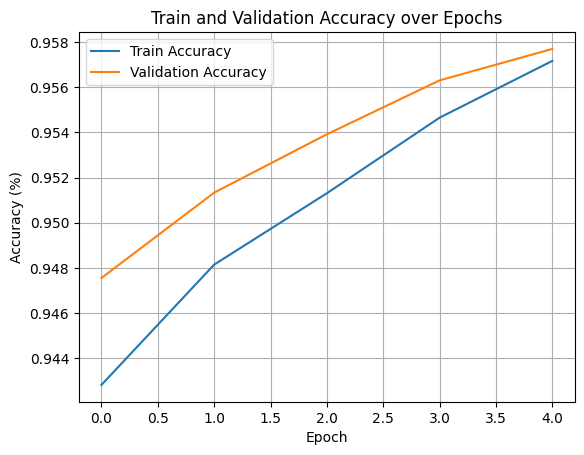

In [ ]:
# accuracy plot
plt.plot(history['epoch'], history['train_accuracy'], label='Train Accuracy')
plt.plot(history['epoch'], history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Train and Validation Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()

**Question**:
- From the visualization of that plot, do you think that 5 epochs are enough, or should the model train longer than that?
**Answer:** Probably not if the accuracy is still improving after the fifth epoch.
   Usually, training should continue until the validation performance stops getting better.
- Can you find a reason for the validation curve to be consistently higher than the training curve, which in principle should not happen. Hint: look at how the history for train and validation are computed during model training, and correct the plot construction.
**Answer:**  This can happen because training accuracy is measured during training, while validation accuracy is measured separately in evaluation mode.
    The two calculations are not always directly comparable, which can make validation accuracy look slightly better.


